In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 12.3 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import time
import optuna
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

# --- CONFIGURAÇÕES GLOBAIS ---
RANDOM_STATE = 42
N_BOOTSTRAP_ITERATIONS = 1000 # Padrão para significância estatística (95% CI)
NPZ_PATH = '/content/drive/MyDrive/2026/ic/npz_files/hwu_usp_windowed_data_v2.npz'

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
def load_data_and_split(path):
    print(f"Carregando dataset: {path}...")
    try:
        data = np.load(path, allow_pickle=True)
        X_train = data['X_train']
        y_train = data['y_train']
        X_val   = data['X_val']
        y_val   = data['y_val']
        X_test  = data['X_test']
        y_test  = data['y_test']
    except FileNotFoundError:
        print("Erro: Arquivo não encontrado.")
        return None

    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

def prep_data(X, mode='raw'):
    """Centraliza a lógica: Raw (Flatten) ou Features (Stats)"""
    if mode == 'raw':
        # Flatten: (N, Time, Sensors) -> (N, Time*Sensors)
        return X.reshape(X.shape[0], -1)
    elif mode == 'features':
        # Stats: Média, Std, Max, Min
        return np.hstack([
            np.mean(X, axis=1),
            np.std(X, axis=1),
            np.max(X, axis=1),
            np.min(X, axis=1)
        ])
    return X

In [5]:
def run_optuna(X_tr, y_tr, X_val, y_val, mode_name):
    """Busca melhores hiperparâmetros de forma eficiente e reprodutível."""
    def objective(trial):
        # Espaço de Busca Padronizado
        n_estimators = trial.suggest_int('n_estimators', 100, 1000)

        # Lógica para max_depth: [10, 50] ou None
        if trial.suggest_categorical('max_depth_is_none', [True, False]):
            max_depth = None
        else:
            max_depth = trial.suggest_int('max_depth', 10, 50)

        min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
        max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
        class_weight = trial.suggest_categorical('class_weight', [None, 'balanced', 'balanced_subsample'])

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            min_samples_split=min_samples_split,
            max_features=max_features,
            class_weight=class_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        return f1_score(y_val, preds, average='macro')

    print(f"\n [Optuna] Otimizando: {mode_name}...")
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    # Adiciona Sampler com seed para reprodutibilidade total
    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
    study = optuna.create_study(direction='maximize', sampler=sampler)
    study.optimize(objective, n_trials=50) # 50 trials conforme solicitado

    # Limpa os parâmetros para que o construtor do Random Forest não receba argumentos inválidos
    best_params = study.best_params.copy()
    if best_params.pop('max_depth_is_none', False):
        best_params['max_depth'] = None

    print(f"   Best Params: {best_params}")
    return best_params

In [6]:
def run_experiment(X_train, y_train, X_test, y_test, params, mode_name):
    """
    EXPERIMENTO: Treina o modelo com os melhores parâmetros e gera as previsões
    para posterior avaliação via Bootstrap.
    """
    print(f"\n[Treinamento] Executando: {mode_name}")
    start = time.time()

    # Configurar Modelo com base nos parâmetros
    if params == 'balanced':
        model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
    else:
        p = params.copy()
        model = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **p)

    # Treino (100% dos dados de treino)
    model.fit(X_train, y_train)

    # Previsão
    y_pred = model.predict(X_test)
    duration = time.time() - start

    print(f"   Treinamento concluído em {duration:.2f}s")

    # Retornamos y_pred para calcular TODAS as métricas via Bootstrap depois
    return y_pred

In [7]:
def run_bootstrap_experiment(y_test, y_pred, n_iterations=1000):
    """
    Calcula F1-Score e Acurácia utilizando Bootstrap para gerar média e Intervalo de Confiança.
    """
    f1_stats = []
    acc_stats = []

    print(f"[Bootstrap] Calculando métricas (95% CI) com {n_iterations} iterações...", end="")

    for _ in range(n_iterations):
        # Reamostra índices com reposição
        y_true_resample, y_pred_resample = resample(y_test, y_pred, random_state=None)

        f1_stats.append(f1_score(y_true_resample, y_pred_resample, average='macro'))
        acc_stats.append(accuracy_score(y_true_resample, y_pred_resample))

    print(" Feito.")

    return {
        'F1_Mean': np.mean(f1_stats),
        'F1_CI_Lower': np.percentile(f1_stats, 2.5),
        'F1_CI_Upper': np.percentile(f1_stats, 97.5),
        'Acc_Mean': np.mean(acc_stats),
        'Acc_CI_Lower': np.percentile(acc_stats, 2.5),
        'Acc_CI_Upper': np.percentile(acc_stats, 97.5)
    }

Carregando dataset: /content/drive/MyDrive/2026/ic/npz_files/hwu_usp_windowed_data_v2.npz...

[Treinamento] Executando: Raw + Balanced
   Treinamento concluído em 0.54s
[Bootstrap] Calculando métricas (95% CI) com 1000 iterações... Feito.

 [Optuna] Otimizando: Raw + Optimized...
   Best Params: {'n_estimators': 505, 'min_samples_split': 17, 'min_samples_leaf': 7, 'max_features': 'log2', 'class_weight': None, 'max_depth': None}

[Treinamento] Executando: Raw + Optimized
   Treinamento concluído em 0.99s
[Bootstrap] Calculando métricas (95% CI) com 1000 iterações... Feito.

[Treinamento] Executando: Features + Balanced
   Treinamento concluído em 0.21s
[Bootstrap] Calculando métricas (95% CI) com 1000 iterações... Feito.

 [Optuna] Otimizando: Features + Optimized...
   Best Params: {'n_estimators': 111, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': None, 'class_weight': None, 'max_depth': None}

[Treinamento] Executando: Features + Optimized
   Treinamento concluído em

,Cenário,F1_Mean,F1_CI_Lower,F1_CI_Upper,Acc_Mean,Acc_CI_Lower,Acc_CI_Upper
0,Raw + Balanced,0.403391,0.380808,0.426253,0.416160,0.392612,0.439050
1,Raw + Optimized,0.391720,0.369212,0.414100,0.400806,0.378364,0.423219
2,Features + Balanced,0.478823,0.455428,0.503183,0.479701,0.456992,0.502375
3,Features + Optimized,0.476982,0.453968,0.498616,0.472625,0.450132,0.492902


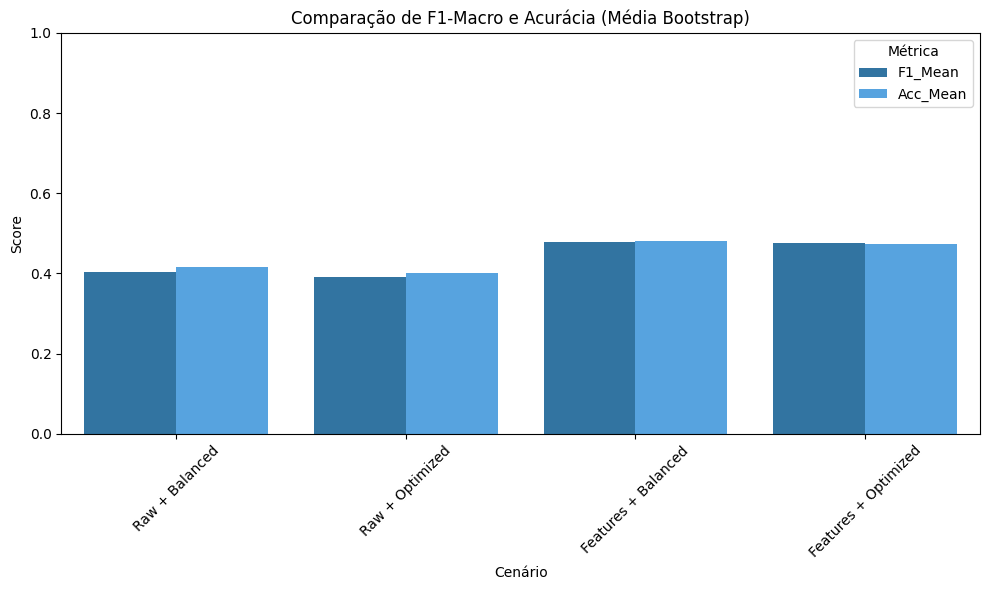

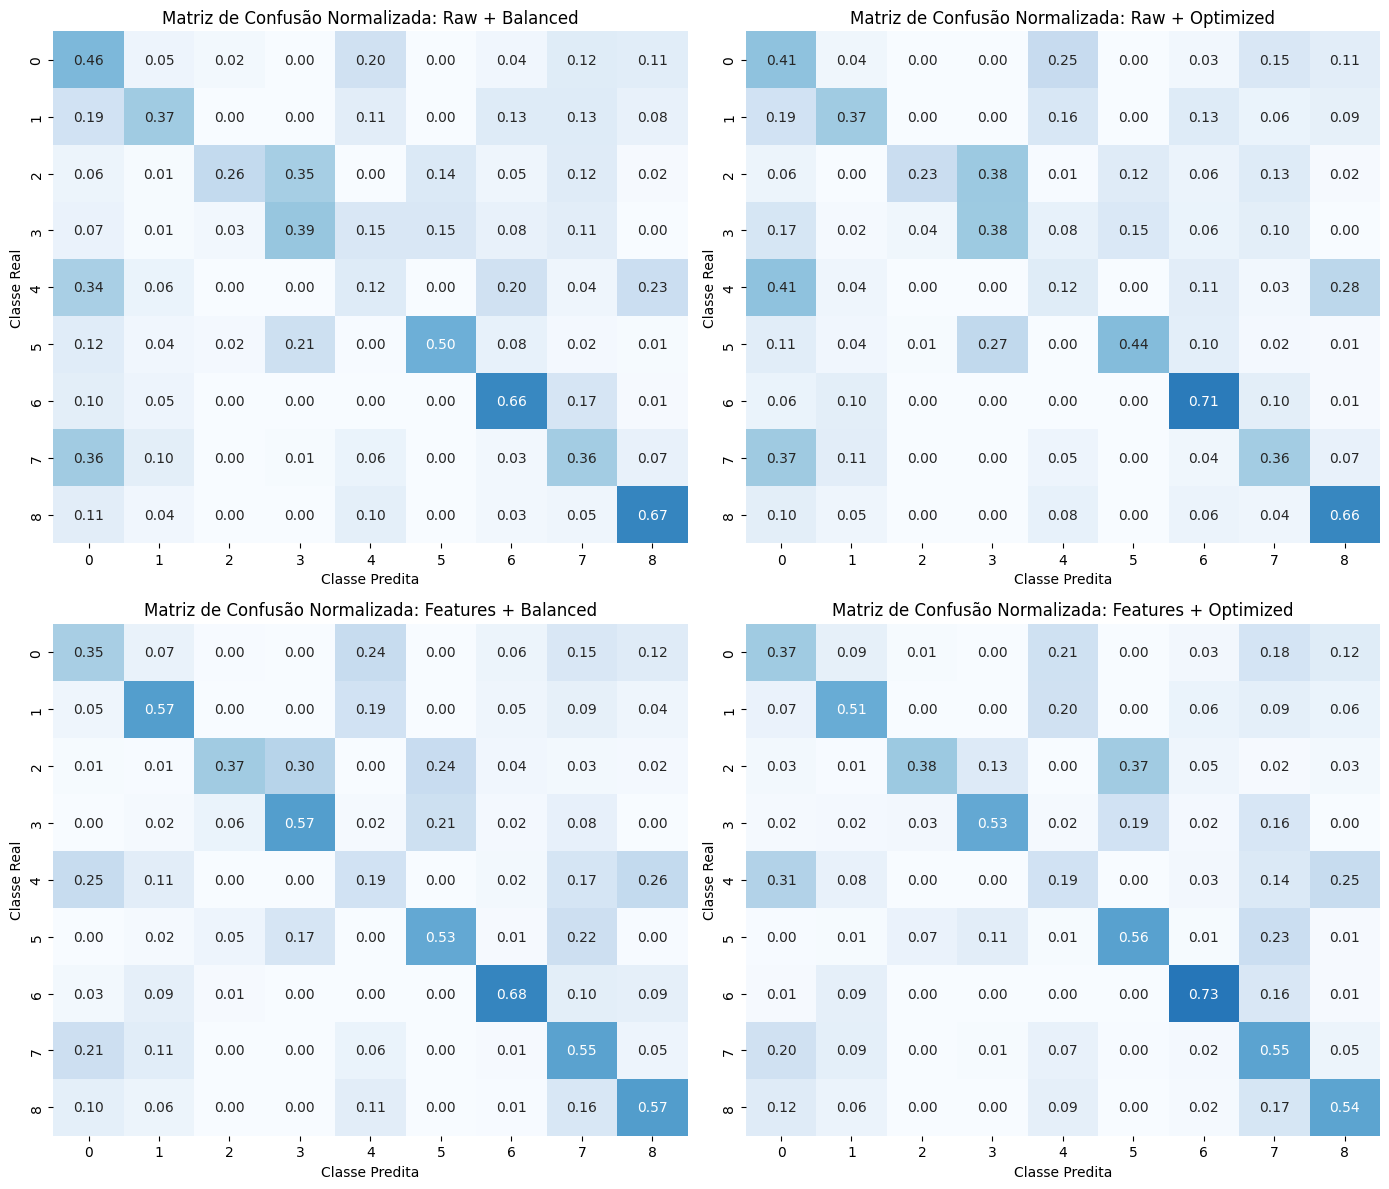

In [8]:
# 1. Carregar Dados
splits = load_data_and_split(NPZ_PATH)
from IPython.display import display

if splits:
    (X_tr, y_tr), (X_val, y_val), (X_te, y_te) = splits
    final_report = []
    confusion_matrices = {}

    scenarios = [("Raw", "balanced"), ("Raw", "optimized"), ("Features", "balanced"), ("Features", "optimized")]

    for data_type, param_type in scenarios:
        scenario_label = f"{data_type} + {param_type.capitalize()}"
        mode = 'raw' if data_type == 'Raw' else 'features'

        # 1. PREPARAÇÃO (Flatten ou Stats)
        X_tr_run = prep_data(X_tr, mode)
        X_val_run = prep_data(X_val, mode)
        X_te_run = prep_data(X_te, mode)

        # 2. OTIMIZAÇÃO (OPTUNA)
        if param_type == 'optimized':
            best_params = run_optuna(X_tr_run, y_tr, X_val_run, y_val, scenario_label)
        else:
            best_params = 'balanced'

        # 3. EXPERIMENTO (Apenas Treino e Predição)
        y_pred = run_experiment(
            X_tr_run, y_tr, X_te_run, y_te, best_params, scenario_label
        )

        # Salva a matriz de confusão do cenário (Normalizada)
        confusion_matrices[scenario_label] = confusion_matrix(y_te, y_pred, normalize='true')

        # 4. BOOTSTRAP (Métricas Reais)
        boot_stats = run_bootstrap_experiment(y_te, y_pred, n_iterations=N_BOOTSTRAP_ITERATIONS)

        # 5. SALVAR RESULTADOS
        result_row = {
            'Cenário': scenario_label,
            'Tipo Dados': data_type,
            'Estratégia': param_type,
            'F1_Mean': boot_stats['F1_Mean'],
            'F1_CI_Lower': boot_stats['F1_CI_Lower'],
            'F1_CI_Upper': boot_stats['F1_CI_Upper'],
            'Acc_Mean': boot_stats['Acc_Mean'],
            'Acc_CI_Lower': boot_stats['Acc_CI_Lower'],
            'Acc_CI_Upper': boot_stats['Acc_CI_Upper']
        }
        final_report.append(result_row)

        # Limpeza de memória forçada para evitar crash no Colab
        del X_tr_run, X_te_run
        import gc; gc.collect()

    # -------------------------------------------------
    # RELATÓRIO FINAL E VISUALIZAÇÕES
    # -------------------------------------------------
    df_results = pd.DataFrame(final_report)
    print("\n\n=== TABELA DE RESULTADOS (VIA BOOTSTRAP) ===")
    display(df_results[['Cenário', 'F1_Mean', 'F1_CI_Lower', 'F1_CI_Upper', 'Acc_Mean', 'Acc_CI_Lower', 'Acc_CI_Upper']])

    # Plot Visual - Gráfico de Barras Azul comparando F1 e Acurácia
    df_melt = df_results.melt(id_vars='Cenário', value_vars=['F1_Mean', 'Acc_Mean'], var_name='Métrica', value_name='Valor (Média Bootstrap)')

    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_melt, x='Cenário', y='Valor (Média Bootstrap)', hue='Métrica', palette=['#1f77b4', '#41a5f5'])
    plt.title('Comparação de F1-Macro e Acurácia (Média Bootstrap)')
    plt.ylabel('Score')
    plt.ylim(0.0, 1.0)
    plt.xticks(rotation=45)
    plt.legend(title="Métrica")
    plt.tight_layout()
    plt.show()

    # Plot Visual - Matrizes de Confusão
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    for i, (cenario, cm) in enumerate(confusion_matrices.items()):
        sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=axes[i], cbar=False, vmin=0, vmax=1)
        axes[i].set_title(f'Matriz de Confusão Normalizada: {cenario}')
        axes[i].set_xlabel('Classe Predita')
        axes[i].set_ylabel('Classe Real')
    plt.tight_layout()
    plt.show()

else:
    print(" Falha no carregamento dos dados. Verifique o caminho do arquivo.")